<h1>Bank Customer Churn Analysis</h1>

<h3><u>Introduction</u></h3>

This project analyzes a bank customer churn dataset to identify factors associated with customer attrition. Using Python and pandas, the analysis explores customer demographics, account characteristics, and behavioral attributes to understand which customer segments exhibit higher churn rates.

The objective is to answer business-focused questions that can help the bank improve customer retention and prioritize high-risk customer segments.

<h3><u>Importing libraries</u></h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<h3><u>Reading Data</u></h3>

In [2]:
Data = pd.read_csv("Churn_Modelling.csv")

<h3><u>Inspecting</u></h3>

In [3]:
Data.head(10) #checking file imported properly

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
Data.tail() #checking no additional row such as total is not included

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
Data.info() #checking data types and non null count and missingno redundant and isna()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
Data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
Data.shape

(10000, 14)

In [8]:
Data.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [9]:
Data.duplicated().sum()

np.int64(0)

In [10]:
Data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

<h3><u>Cleaning </u></h3>

In [11]:
Data.rename(columns={"RowNumber": "Row"}, inplace=True)
Data = Data.set_index("Row")

In [12]:
Data[(Data["Age"] < 0) | (Data["Age"] > 100)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Row,,,,,,,,,,,,,


In [13]:
Data[(Data["HasCrCard"] < 0) | (Data["HasCrCard"] > 1)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Row,,,,,,,,,,,,,


In [14]:
Data[(Data["IsActiveMember"] < 0) | (Data["IsActiveMember"] > 1)]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Row,,,,,,,,,,,,,


In [15]:
Data[Data["EstimatedSalary"] < 0 ]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Row,,,,,,,,,,,,,


- No missing values detected.
- No duplicate rows detected.
- Numeric columns have appropriate data types.
- No inconsistent categorical values observed.
- Set `RowNumber` as the index for convenience.

<H3><u>EDA :- Exploratory Data Analysis</u></H3>

<H5> Business Question 1 :- </H5> <H5> What is the overall customer churn rate? </H5>



In [16]:
Churn_Rate = round(Data["Exited"].mean()*100,2)
Churn_Rate

np.float64(20.37)

<H5>Insight :- </H5>

> Approximately one in five customers have exited the bank, indicating a meaningful customer retention challenge.

<H5> Business Question 2 :- </H5>

<H5> Does customer's gender influence churn? </H5>

In [17]:
Gen_churn = round(Data.groupby("Gender")["Exited"].mean()*100,2).to_frame("Churn Rate")
Gen_churn

,Churn Rate
Gender,
Female,25.07
Male,16.46


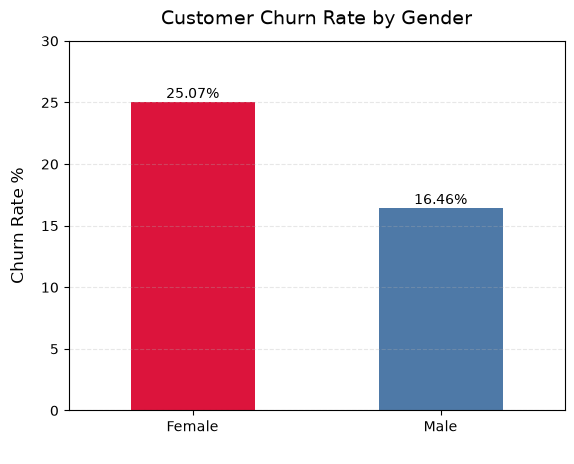

In [18]:
ax = Gen_churn["Churn Rate"].plot(kind="bar",color=["crimson","#4E79A7"])

plt.title("Customer Churn Rate by Gender",fontsize=14, pad=12)

plt.legend().remove()
plt.grid(axis= "y",linestyle="--",alpha = 0.3)
plt.xlabel(" ")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,30)

for i,v in enumerate(Gen_churn["Churn Rate"]): # i = bar position (0,1) v = bar height (12,25.07)
    ax.text(i,v + 0.3, f"{v:.2f}%", ha="center")
plt.show()

<H5>Insight :- </H5>

> Female customer are leaving more than Male customer by 8.61% .

<H5> Business Question 3 :- </H5>

<H5> Does Geography influence churn? </H5>

In [19]:
Geo_churn=round(Data.groupby("Geography")["Exited"].mean()*100,2).to_frame("Churn Rate")
Geo_churn

,Churn Rate
Geography,
France,16.15
Germany,32.44
Spain,16.67


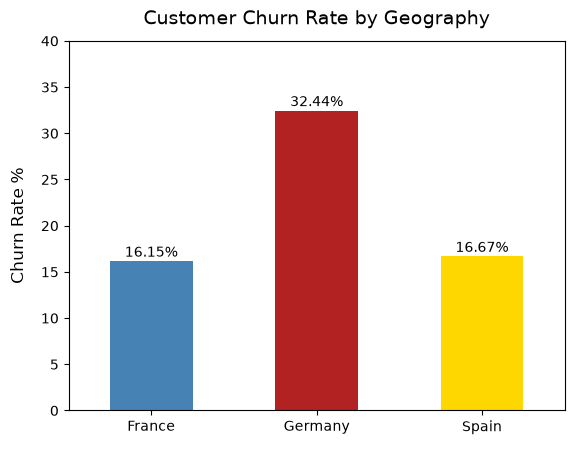

In [20]:
ax = Geo_churn["Churn Rate"].plot(kind="bar",color=["steelblue", "firebrick", "gold"])
plt.title("Customer Churn Rate by Geography",fontsize=14, pad=12)
plt.legend().remove()

plt.xlabel(" ")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,40)
for i,v in enumerate(Geo_churn["Churn Rate"]): # i = bar position (0,1) v = bar height (12,25.07)
    ax.text(i,v + 0.5, f"{v:.2f}%", ha="center")
plt.show()

<H5>Insight :- </H5>

> So Germany is high risk enviournment. Customer From Germany are leaving at almost double the rate of France and Spain.


<H5> Business Question 4 :- </H5>

<H5> Does Active Member influence churn? </H5>

In [21]:
Active_churn = round(Data.groupby("IsActiveMember")["Exited"].mean()*100,2).to_frame("Churn Rate")
Active_churn.index =["Inactive","Active"]
Active_churn

,Churn Rate
Inactive,26.85
Active,14.27


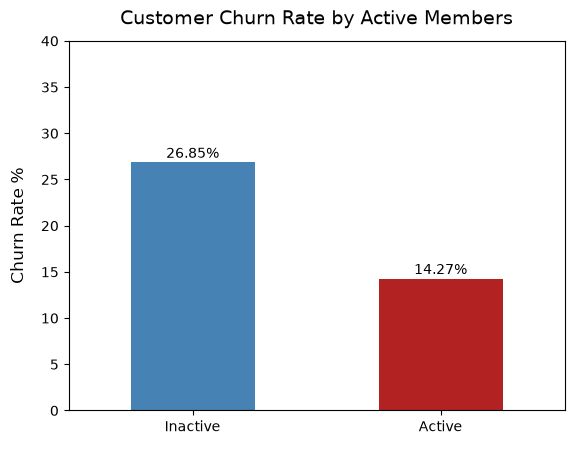

In [22]:
ax = Active_churn["Churn Rate"].plot(kind="bar",color=["steelblue", "firebrick", "gold"])
plt.title("Customer Churn Rate by Active Members",fontsize=14, pad=12)
plt.legend().remove()

plt.xlabel(" ")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,40)
for i,v in enumerate(Active_churn["Churn Rate"]): # i = bar position (0,1) v = bar height (12,25.07)
    ax.text(i,v + 0.5, f"{v:.2f}%", ha="center")
plt.show()

<H5>Insight :- </H5>

>  Inactive Members are leaving at almost double the rate of Active Members.


<H5> Business Question 5 :- </H5>

<H5> Does Age influence churn? </H5>

In [23]:
Data["Age_Groups"] = pd.cut(Data["Age"],bins=[18,30,40,50,60,70,80,90,100],right=False,labels=["18-29","30-39","40-49","50-59","60-69","70-79","80-89","90+"])

In [24]:
Age_churn = round(Data.groupby("Age_Groups")["Exited"].mean()*100,2).to_frame("Churn Rate")
Age_churn = Age_churn.drop("90+")
Age_churn

,Churn Rate
Age_Groups,
18-29,7.56
30-39,10.88
40-49,30.79
50-59,56.04
60-69,35.20
70-79,10.29
80-89,7.69


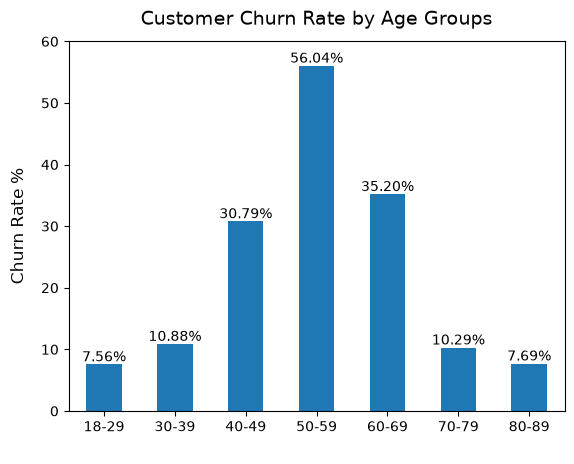

In [25]:
ax= Age_churn["Churn Rate"].plot(kind="bar",)
plt.title("Customer Churn Rate by Age Groups",fontsize=14, pad=12)
plt.ylabel("Churn Rate %", fontsize=12,labelpad=10)
plt.xlabel(" ")
plt.xticks(rotation=0)
plt.ylim(0,60)
for i,v in enumerate(Age_churn["Churn Rate"]):
    ax.text(i,v + 0.5,f"{v:.2f}%",ha = "center")
plt.show()

In [26]:
Data["Age_Groups"].value_counts()

Age_Groups
30-39    4346
40-49    2618
18-29    1641
50-59     869
60-69     375
70-79     136
80-89      13
90+         2
Name: count, dtype: int64

<H5>Insight :- </H5>

>  Churn increases steadily from younger age groups, peaks among customers aged 50–59 (56.04%), and then declines across older age groups.


>  Age groups with very small sample sizes can produce unstable churn rates. The 90+ group contained only two customers and was excluded from the visualization to avoid misleading conclusions.


<H5> Business Question 6 :- </H5>

<H5> Does older customers in Germany churn more than younger ones? </H5>

In [27]:
Ger_churn = round(Data[Data["Geography"]== "Germany"].groupby("Age_Groups")["Exited"].mean()*100,2).to_frame("Churn Rate")
Ger_churn = Ger_churn.drop("80-89")

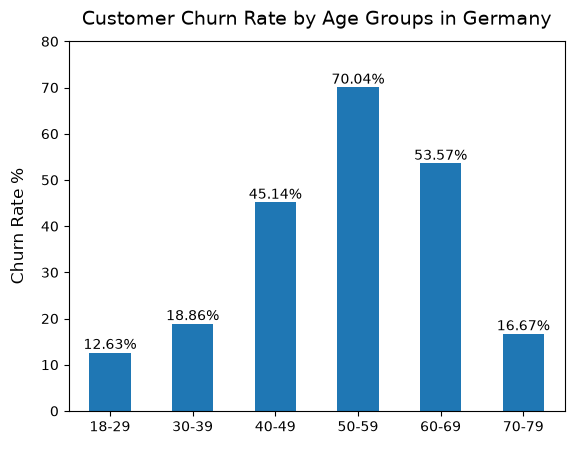

In [28]:
ax = Ger_churn["Churn Rate"].plot(kind="bar")
plt.title("Customer Churn Rate by Age Groups in Germany",fontsize=14, pad=12)
plt.xlabel(" ")
plt.xticks(rotation= 0)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,80)
for i,v in enumerate(Ger_churn["Churn Rate"]):
    ax.text(i,v + 0.8,f"{v:.2f}%",ha="center")
plt.show()  

In [29]:
Data[Data["Geography"]== "Germany"]["Age_Groups"].value_counts(sort=False)

Age_Groups
18-29    372
30-39    997
40-49    740
50-59    277
60-69     84
70-79     36
80-89      3
90+        0
Name: count, dtype: int64

<H5>Insight :- </H5>

> Churn increases with age, peaks at 50–59 (70.04%), and then declines in the older age groups. 

> The 80–89 age group was excluded due to its very small sample size (3 customers)

> The 90+ age group was not included because there were no customers in this category.

<H5> Business Question 7 :- </H5>

<H5> Among inactive customers, does balance influence churn? </H5>

In [30]:
Data["Bal_Groups"] = pd.cut(Data["Balance"],bins=[-1, 0, 50000, 100000, 150000, 200000,300000],labels=["0","1-50k","50k-100k","100k-150k","150k-200k","200+"])

In [31]:
Bal_churn = round(Data[Data["IsActiveMember"]== 0].groupby("Bal_Groups")["Exited"].mean()*100,2).to_frame("Churn Rate")
Bal_churn

,Churn Rate
Bal_Groups,
0,18.35
1-50k,51.43
50k-100k,26.89
100k-150k,33.49
150k-200k,29.46
200+,42.11


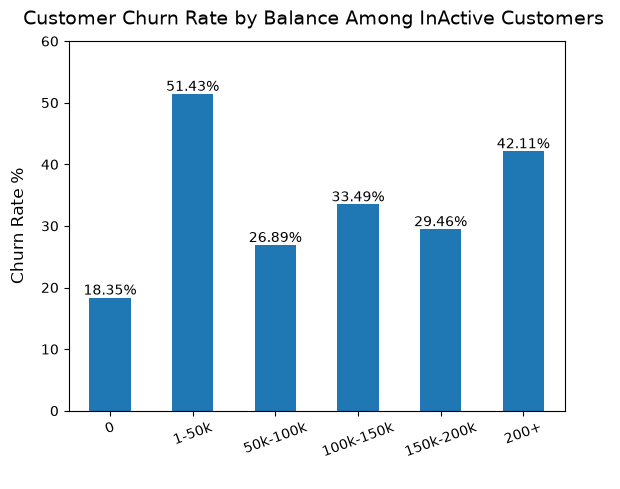

In [32]:
ax = Bal_churn["Churn Rate"].plot(kind="bar")
plt.title("Customer Churn Rate by Balance Among InActive Customers ",fontsize=14, pad=12)
plt.xlabel(" ")
plt.xticks(rotation=20)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,60)
for i,v in enumerate(Bal_churn["Churn Rate"]):
    ax.text(i,v + 0.5,f"{v:.2f}%",ha = "center")
plt.show()

In [33]:
Data["Bal_Groups"].value_counts(sort=False)

Bal_Groups
0            3617
1-50k          75
50k-100k     1509
100k-150k    3830
150k-200k     935
200+           34
Name: count, dtype: int64

<H5>Insight :- </H5>

> Among inactive customers, churn is lowest for customers with a zero balance (18.4%) but increases sharply for those with balances between 1–50K (51.3%).

> Churn remains relatively high across the higher balance groups, with the 200K+ group also showing elevated churn (42.1%). 

> This suggests that inactive customers with positive account balances are generally more likely to leave than those with no balance.

<H5> Business Question 8 :- </H5>

<H5> Does having credit card have a relationship with churn? </H5>

In [34]:
Data.sample()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Groups,Bal_Groups
Row,,,,,,,,,,,,,,,
3205,15603942,Hawthorn,547,Germany,Male,50,3,81290.02,3,0,1,177747.03,1,50-59,50k-100k


In [35]:
Crd_churn = round(Data.groupby("HasCrCard")["Exited"].mean()*100,2).to_frame("Churn Rate")
Crd_churn.index = ["No Credit Card", "Credit Card"]
Crd_churn

,Churn Rate
No Credit Card,20.81
Credit Card,20.18


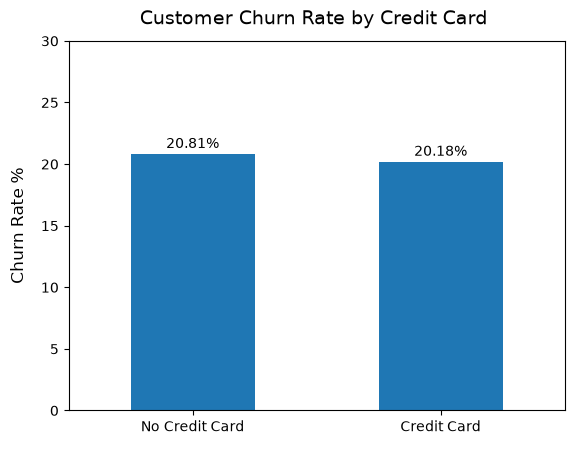

In [36]:
ax = Crd_churn["Churn Rate"].plot(kind="bar")
plt.title("Customer Churn Rate by Credit Card ",fontsize=14, pad=12)
plt.xlabel(" ")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate %",fontsize=12,labelpad=10)
plt.ylim(0,30)
for i,v in enumerate(Crd_churn["Churn Rate"]):
    ax.text(i,v + 0.5,f"{v:.2f}%",ha = "center")
plt.show()

<H5>Insight :- </H5>

> Customers with and without a credit card have nearly identical churn rates (20.81% vs. 20.18%).

> This suggests that credit card ownership has little to no apparent relationship with customer churn in this dataset.

<H3><u>Summary of Findings</H3></u>

The exploratory analysis identified several customer segments with substantially higher churn rates.

> Overall customer churn is 20.37%, indicating that approximately one in five customers leave the bank.

> Female customers churn at 25.07% compared to 16.46% for male customers — a gap of over 8 percentage points.

> Germany shows a churn rate of 32.44%, nearly double that of France (16.15%) and Spain (16.67%), making it the highest-risk geographic segment.

> Inactive customers churn at 26.85% versus 14.27% for active customers, suggesting engagement is strongly linked to retention.

> Churn peaks sharply in the 50–59 age group at 56.04%, then declines in older groups. The 90+ group was excluded due to insufficient sample size (2 customers).

> Within Germany specifically, churn again peaks at 50–59 (70.04%). The 80–89 group was excluded due to small sample size (3 customers).

>Among inactive customers, customers with zero balance churn at only 18.35% while those with balances of 1–50K shows the highest churn at      51.43%. and high-balance customers (200K+) also show elevated churn at 42.11%.

>Credit card ownership has no meaningful relationship with churn — holders and non-holders churn at nearly identical rates (20.18% vs. 20.81%).